<div class="alert alert-block alert-danger">
    <b> UNTANGLING THE CYTOSKELETON: A MODEL TO DESCRIBE CYTOSKELETAL ORGANIZATION - CODE</b> 
    
 **6 - RESULTS ANALYSIS**
    
**Author**: Diogo Fróis Vieira
</div>

<div class="alert alert-block alert-info">
    
 **IMPORTS**
    
</div>

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))
import pandas as pd
import numpy as np
import math
import pickle
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from IPython.display import display
from packageCYSK.importing import *
from packageCYSK.visualization import *


print('📚 All libraries successfully imported 📚')

📚 All libraries successfully imported 📚


<div class="alert alert-block alert-info">
    
 **DIRECTORIES**
    
</div>

In [2]:
# Define dataset folder.
folder      = os.getcwd() + "\\data"

# Import images from CYTO, NUCL and RGB folders.
options     = ["CYTO"]

# Dictionary with keys "CYTO", "NUCL", "RGB".
data = init_import(folder,options)

ROIs = pd.read_pickle(folder + "\\ROIs\\ROIs_HPA_TEST2.pkl")

# Import processed results
ResultsDF = pd.read_pickle(folder + "\\ResultsDF_TEST_DONE.pkl")


Voxel depth (Z-spacing) could not be determined. Set to 1 (default).
>>> [CYTO] added.


In [3]:
ResultsDF['LSF3D:Mat Scores'] = pd.read_pickle(folder + "\\rsmatscoresvector_9_jan_24.pkl")

In [3]:
sep = create_separate_DFs(ResultsDF,options=["FULL"])
FULL = sep["FULL"]

C:\Users\diogo\OneDrive - Universidade de Lisboa\Ambiente de Trabalho\CYSK_Workspace\packageCYSK\processing.py:1007: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res += [(prefix + " kurtosis",kurtosis(data_array))]
C:\Users\diogo\OneDrive - Universidade de Lisboa\Ambiente de Trabalho\CYSK_Workspace\packageCYSK\processing.py:1008: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res += [(prefix + " skewness",skew(data_array))]
C:\Users\diogo\OneDrive - Universidade de Lisboa\Ambiente de Trabalho\CYSK_Workspace\packageCYSK\processing.py:1007: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res += [(prefix + " kurtosis

<div class="alert alert-block alert-info">
    
 **INSTRUCTIONS**
    
</div>

**1.** Import a dataframe with results.

**2.** You can either analyze

- **OPTION 1:** select a specific cell from the dataframe 

- **OPTION 2:** and/or the whole dataset of cells (global analysis)

<div class="alert alert-block alert-info">
    
 **SELECT CELL**
    
</div>

In [3]:
def dropdown_cell_eventhandler(change):
    global cell
    cell = dropdown_image.value
    lab = ResultsDF.loc[cell]['Label']
    print('Cell ' + str(cell) + ' (' + str(lab) +') selected.')

dropdown_image = widgets.Dropdown(description =  'Select Cell:' , options = ['...'] + list(ResultsDF.index))
dropdown_image.observe(dropdown_cell_eventhandler, names='value')
display(dropdown_image)

Dropdown(description='Select Cell:', options=('...', 0), value='...')

Cell 0 (Cells) selected.


<div class="alert alert-block alert-info">
    
 **PLOT INTENSITY**
    
</div>

ValueError: too many values to unpack (expected 2)

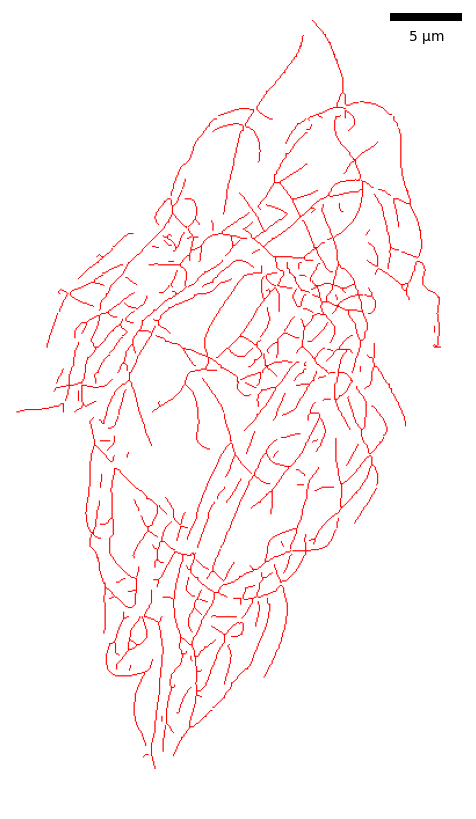

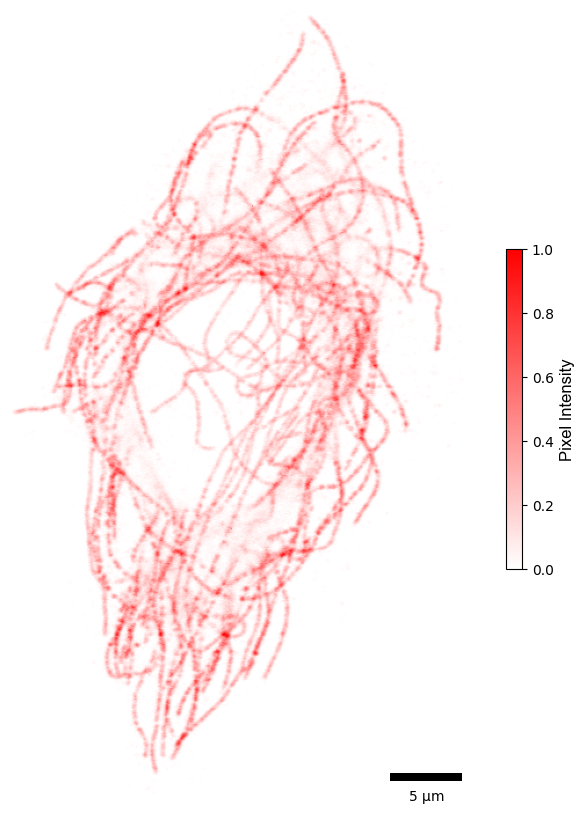

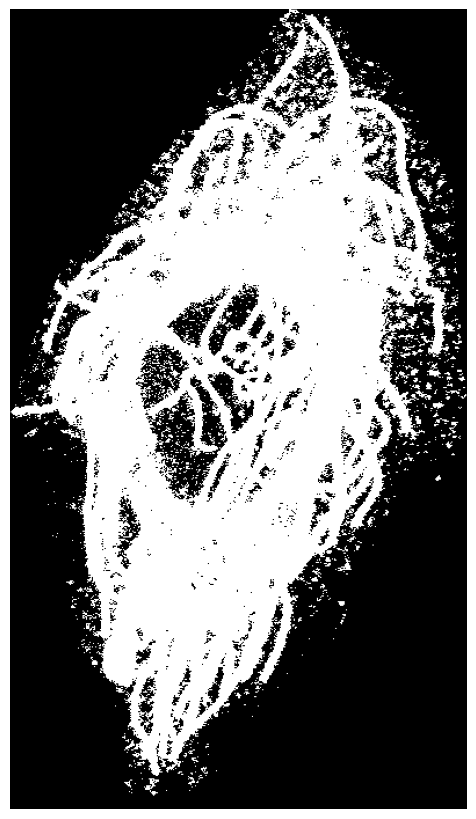

In [4]:
fig_sk,fig_int = intensity_plotter(ResultsRow = ResultsDF.loc[cell],
                                  data       = data,
                                  save       = False)   

<div class="alert alert-block alert-info">
    
 **PLOT LINES**
    
</div>

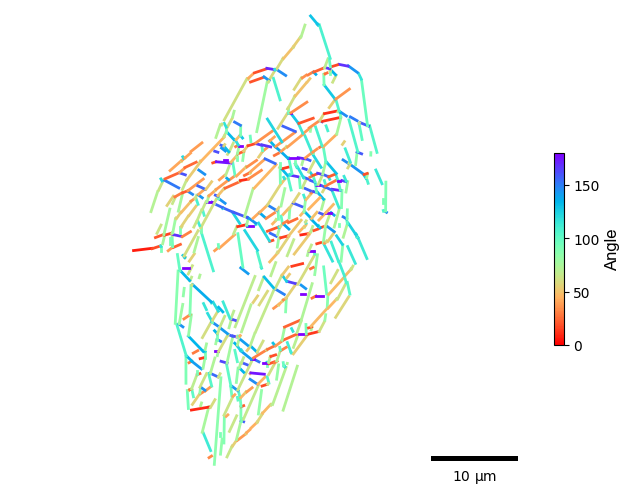

In [6]:
# PLOT LINES
%matplotlib inline

cmap     = pltc.rainbow_r
cm       = truncate_colormap(cmap, 0, 1, 300)

# ORIENTATION
fig_lines = line_plotter(ResultsRow = ResultsDF.loc[cell],
             data=data,
             feat='LSF2D:Theta',
             cmap=cm,
             normalize_bounds=[0, 180],
             colorbar_label='Angle',
             overlay=False,
             save='orientation_lines_exp')

# BUNDLING
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat="LSF2D:Local Line Distance (LinReg)",
#              cmap=cm,
#              normalize_bounds=[0,4],
#              colorbar_label='Local Line Distance (µ)',
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save='bundling_lines0')

# PARALLELISM
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat="LSF2D:Angle Difference (LinReg)",
#              cmap=cm,
#              normalize_bounds=[0,90],
#              colorbar_label='Mean Angle Difference (º)',
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save='parallelism_lines2')

# COMPACTNESS & QUANTITY
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat=None,
#              cmap=cm,
#              normalize_bounds=None,
#              colorbar_label=None,
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save='compactness_lines1')

# RADIALITY
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat="LSF2D:Alphas (LinReg)",
#              cmap=cm,
#              normalize_bounds=[0,90],
#              colorbar_label='Angle (º)',
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save=False)

# CYTO-NUC INTERACTION
# line_plotter(ResultsRow = ResultsDF.loc[cell],
#              data=data,
#              feat="LSF2D:Distances to Centroid (LinReg) (scaled)",
#              cmap=cm,
#              normalize_bounds=[0,30],
#              colorbar_label='Distance (μm)',
#              line_data_origin = 'Lines LinReg',
#              overlay=False,
#              save='cytonuc_lines0')

C:\Users\diogo\AppData\Local\Temp\ipykernel_5652\989134141.py:60: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


Done.


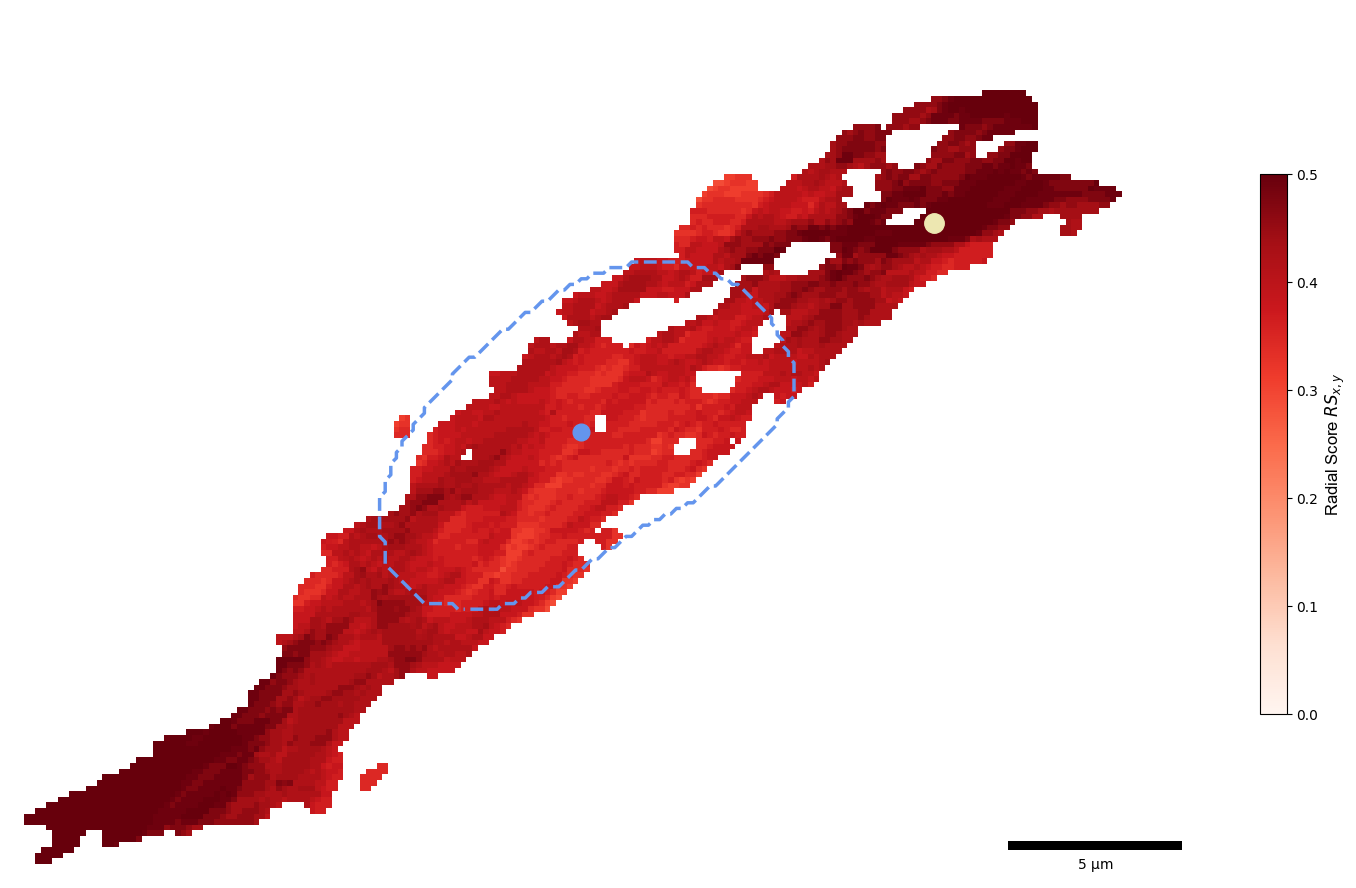

In [21]:
fig_rad = plot_radial(ResultsRow       = ResultsDF.loc[488], 
                      overlay          = None, 
                      normalize_bounds = 'default',
                      colorbar_label   = 'Radial Score $RS_{x,y}$',
                      save             = "RS2_map") 

<div class="alert alert-block alert-info">
    
 **PLOT GRAPH**
    
</div>

KeyError: 'SKNW:branch-distance'

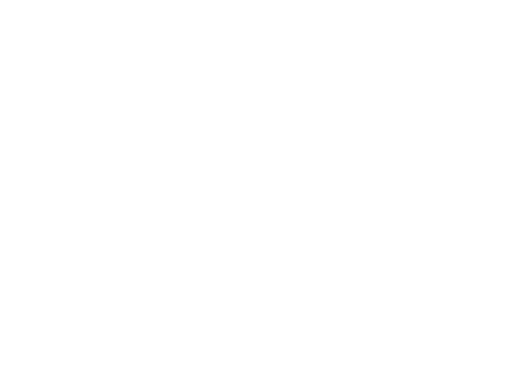

In [7]:
cmap     = pltc.rainbow
cm       = truncate_colormap(cmap, 0, 1, 300)

fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[cell],
                          data             = data,
                          feat             = 'SKNW:branch-distance',
                          cmap             = cm,
                          normalize_bounds = [0,6],
                          colorbar_label   = 'Length (μm)',
                          nodes            = True,
                          main_branch      = False,
                          overlay          = None,
                          scalebar         = True,
                          save             = 'morphology_graph_fig4c')

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Branch Orientation',
#               cmap             = cm,
#               normalize_bounds = [0,180],
#               colorbar_label   = 'Angle (º)',
#               nodes            = True,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Local Average Branch Distance',
#               cmap             = cm,
#               normalize_bounds = 'default',
#               colorbar_label   = 'Distance (μm)',
#               nodes            = False,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Mean Filament Thickness',
#               cmap             = cm,
#               normalize_bounds = [1,2],
#               colorbar_label   = 'Thickness (μm)',
#               nodes            = False,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Local Average Branch Orientation',
#               cmap             = cm,
#               normalize_bounds = 'default',
#               colorbar_label   = 'Angle (º)',
#               nodes            = False,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'CNF2D:Local Average Bundling Score',
#               cmap             = cm,
#               normalize_bounds = 'default',
#               colorbar_label   = 'Distance * Angle (umº)',
#               nodes            = False,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = False)

# fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#                           data             = data,
#                           feat             = 'CNF2D:Distances to Centroid',
#                           cmap             = cm,
#                           normalize_bounds = 'default',
#                           colorbar_label   = 'Distance (μm)',
#                           nodes            = False,
#                           main_branch      = False,
#                           overlay          = None,
#                           scalebar         = True,
#                           save             = False)

# fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               cmap             = cm,
#               feat             = None,
#               normalize_bounds = 'default',
#               colorbar_label   = None,
#               nodes            = True,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = 'figure4_graph')

# fig_graph = graph_plotter(ResultsRow       = ResultsDF.loc[cell],
#               data             = data,
#               feat             = 'branch-type',
#               cmap             = cm,
#               normalize_bounds = 'default',
#               colorbar_label   = None,
#               nodes            = True,
#               main_branch      = False,
#               overlay          = None,
#               scalebar         = True,
#               save             = 'connectivity2')

#graph_plotter(ResultsRow=ResultsDF.loc[cell],data=data,feat=None,cmap=cm,normalize_bounds='default',colorbar_label=None,nodes=True,main_branch=False, overlay = None,scalebar=False, save='preprocessing_cellX_paper_graph')